# Search / Retrieval + kNN for Ticket Triage


## 1. Upload the Processed Dataset

Upload the file `ticketmaster_processed_english.csv` from local machine into Colab.

In [4]:
from google.colab import files
uploaded = files.upload()

Saving ticketmaster_processed_english.csv to ticketmaster_processed_english.csv


In [5]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
RANDOM_STATE = 42

## 2. Load the Uploaded CSV

In [6]:
print(os.listdir())

csv_candidates = [f for f in os.listdir() if f.lower().endswith('.csv')]
print('CSV candidates:', csv_candidates)

if not csv_candidates:
    raise FileNotFoundError('No CSV file was uploaded. Please upload ticketmaster_processed_english.csv first.')

preferred_name = 'ticketmaster_processed_english.csv'

if preferred_name in csv_candidates:
    DATA_FILE = preferred_name
else:
    processed_candidates = [f for f in csv_candidates if 'ticketmaster_processed_english' in f]
    if processed_candidates:
        DATA_FILE = sorted(processed_candidates)[-1]
    else:
        DATA_FILE = csv_candidates[0]

print('Using CSV:', DATA_FILE)

df = pd.read_csv(DATA_FILE)
print(df.shape)
print('Loaded columns:', df.columns.tolist())
df.head()


['.config', 'ticketmaster_processed_english.csv', 'sample_data']
CSV candidates: ['ticketmaster_processed_english.csv']
Using CSV: ticketmaster_processed_english.csv
(16338, 19)
Loaded columns: ['subject', 'body', 'combined_text', 'type', 'priority', 'queue', 'language', 'tag_1', 'tag_2', 'answer', 'text_char_len', 'text_word_len', 'version', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


,subject,body,combined_text,type,priority,queue,language,tag_1,tag_2,answer,text_char_len,text_word_len,version,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management ...","Account Disruption Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized ...",Incident,high,Technical Support,en,Account,Disruption,"Thank you for reaching out, <name>. We are aware of the outage affecting the centralized account management system, ...",563,84,51,Outage,IT,Tech Support,NaN,NaN,NaN
1,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed informati...","Query About Smart Home System Integration Features Dear Customer Support Team,\n\nI hope this message reaches you we...",Request,medium,Returns and Exchanges,en,Product,Feature,"Thank you for your inquiry. Our products support integration with Amazon Alexa, Google Assistant, and Apple HomeKit....",585,83,51,Tech Support,NaN,NaN,NaN,NaN,NaN
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching out to request clarification about ...","Inquiry Regarding Invoice Details Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching o...",Request,low,Billing and Payments,en,Billing,Payment,We appreciate you reaching out with your billing questions. The billing period generally begins on the first day of ...,639,95,51,Account,Documentation,Feedback,NaN,NaN,NaN
3,Question About Marketing Agency Software Compatibility,"Dear Support Team,\n\nI hope this message reaches you well. I am reaching out to ask about the compatibility of your...","Question About Marketing Agency Software Compatibility Dear Support Team,\n\nI hope this message reaches you well. I...",Problem,medium,Sales and Pre-Sales,en,Product,Feature,"Thank you for your inquiry. Our product supports integration with major CRM, email marketing, and analytics platform...",732,103,51,Feedback,Tech Support,NaN,NaN,NaN,NaN
4,Feature Query,"Dear Customer Support,\n\nI hope this message reaches you in good health. I am eager to learn more about the feature...","Feature Query Dear Customer Support,\n\nI hope this message reaches you in good health. I am eager to learn more abo...",Request,high,Technical Support,en,Feature,Product,"Thank you for your inquiry. Please specify which product you are interested in, so I can provide detailed informatio...",660,99,51,Documentation,Feedback,NaN,NaN,NaN,NaN


## 3. Keep the Core Columns

In [7]:
required_cols = ['combined_text', 'type', 'priority', 'queue']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

df = df.copy()
df['combined_text'] = df['combined_text'].fillna('').astype(str).str.strip()
df = df[df['combined_text'] != ''].reset_index(drop=True)

print(df.shape)
df[required_cols].head()

(16338, 19)


,combined_text,type,priority,queue
0,"Account Disruption Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized ...",Incident,high,Technical Support
1,"Query About Smart Home System Integration Features Dear Customer Support Team,\n\nI hope this message reaches you we...",Request,medium,Returns and Exchanges
2,"Inquiry Regarding Invoice Details Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching o...",Request,low,Billing and Payments
3,"Question About Marketing Agency Software Compatibility Dear Support Team,\n\nI hope this message reaches you well. I...",Problem,medium,Sales and Pre-Sales
4,"Feature Query Dear Customer Support,\n\nI hope this message reaches you in good health. I am eager to learn more abo...",Request,high,Technical Support


## 4. Prepare the Three Tasks

In [8]:
def prepare_task_frame(data, target_col, min_class_size=5):
    task_df = data[['combined_text', target_col]].copy()
    task_df = task_df.dropna()
    task_df[target_col] = task_df[target_col].astype(str).str.strip()
    task_df = task_df[task_df[target_col] != '']

    counts = task_df[target_col].value_counts()
    keep_labels = counts[counts >= min_class_size].index
    task_df = task_df[task_df[target_col].isin(keep_labels)].reset_index(drop=True)
    return task_df

tasks = {
    'ticket_type': prepare_task_frame(df, 'type'),
    'priority': prepare_task_frame(df, 'priority'),
    'queue': prepare_task_frame(df, 'queue'),
}

for task_name, task_df in tasks.items():
    print(task_name, task_df.shape, 'classes =', task_df.iloc[:, 1].nunique())

ticket_type (16338, 2) classes = 4
priority (16338, 2) classes = 3
queue (16338, 2) classes = 10


## 5. Retrieval + kNN Baseline

We use TF-IDF vectors and a cosine-distance kNN classifier.
Each prediction is based on the labels of the most similar historical tickets.

In [9]:
def train_retrieval_knn(task_df, target_col, task_name, k=5, max_features=15000, ngram_range=(1, 2), min_df=2):
    X = task_df['combined_text']
    y = task_df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=ngram_range,
        min_df=min_df,
    )

    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='cosine',
        weights='distance',
        algorithm='brute',
    )
    knn.fit(X_train_vec, y_train)
    y_pred = knn.predict(X_test_vec)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )

    metrics = pd.DataFrame([{
        'task': task_name,
        'model': f'retrieval_knn_k{k}',
        'train_size': len(X_train),
        'test_size': len(X_test),
        'n_classes': y.nunique(),
        'accuracy': accuracy_score(y_test, y_pred),
        'weighted_precision': precision,
        'weighted_recall': recall,
        'weighted_f1': f1,
    }])

    result = {
        'vectorizer': vectorizer,
        'knn': knn,
        'X_train': X_train.reset_index(drop=True),
        'X_test': X_test.reset_index(drop=True),
        'y_train': y_train.reset_index(drop=True),
        'y_test': y_test.reset_index(drop=True),
        'y_pred': pd.Series(y_pred).reset_index(drop=True),
        'X_train_vec': X_train_vec,
        'X_test_vec': X_test_vec,
    }
    return metrics, result

In [10]:
all_metrics = []
all_results = {}

for task_name, task_df in tasks.items():
    target_col = task_df.columns[1]
    metrics_df, result = train_retrieval_knn(task_df, target_col, task_name, k=5)
    all_metrics.append(metrics_df)
    all_results[task_name] = {
        'target_col': target_col,
        'result': result,
    }

results_df = pd.concat(all_metrics, ignore_index=True)
results_df

,task,model,train_size,test_size,n_classes,accuracy,weighted_precision,weighted_recall,weighted_f1
0,ticket_type,retrieval_knn_k5,13070,3268,4,0.892289,0.890355,0.892289,0.890345
1,priority,retrieval_knn_k5,13070,3268,3,0.759180,0.759202,0.759180,0.758461
2,queue,retrieval_knn_k5,13070,3268,10,0.701652,0.702283,0.701652,0.700602


## 6. Compare Different k Values


In [17]:
def evaluate_multiple_k(task_df, target_col, task_name, k_values=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25)):
  # k_values=(1, 3, 5, 7, 9))
    rows = []
    for k in k_values:
        metrics_df, _ = train_retrieval_knn(task_df, target_col, task_name, k=k)
        rows.append(metrics_df.iloc[0].to_dict())
    return pd.DataFrame(rows)

k_search_results = {}
for task_name, task_df in tasks.items():
    target_col = task_df.columns[1]
    k_search_results[task_name] = evaluate_multiple_k(task_df, target_col, task_name)
    print(f"K search results for {task_name}:")
    display(k_search_results[task_name])

K search results for ticket_type:


,task,model,train_size,test_size,n_classes,accuracy,weighted_precision,weighted_recall,weighted_f1
0,ticket_type,retrieval_knn_k1,13070,3268,4,0.909731,0.909521,0.909731,0.909615
1,ticket_type,retrieval_knn_k2,13070,3268,4,0.909731,0.909521,0.909731,0.909615
2,ticket_type,retrieval_knn_k3,13070,3268,4,0.906059,0.904763,0.906059,0.904924
3,ticket_type,retrieval_knn_k4,13070,3268,4,0.896267,0.894777,0.896267,0.895025
4,ticket_type,retrieval_knn_k5,13070,3268,4,0.892289,0.890355,0.892289,0.890345
5,ticket_type,retrieval_knn_k6,13070,3268,4,0.885863,0.883509,0.885863,0.883459
6,ticket_type,retrieval_knn_k7,13070,3268,4,0.878213,0.875353,0.878213,0.874982
7,ticket_type,retrieval_knn_k8,13070,3268,4,0.873929,0.871046,0.873929,0.870454
8,ticket_type,retrieval_knn_k9,13070,3268,4,0.869033,0.865977,0.869033,0.864849
9,ticket_type,retrieval_knn_k10,13070,3268,4,0.865361,0.862315,0.865361,0.860806


K search results for priority:


,task,model,train_size,test_size,n_classes,accuracy,weighted_precision,weighted_recall,weighted_f1
0,priority,retrieval_knn_k1,13070,3268,3,0.821603,0.821660,0.821603,0.821608
1,priority,retrieval_knn_k2,13070,3268,3,0.821603,0.821660,0.821603,0.821608
2,priority,retrieval_knn_k3,13070,3268,3,0.789780,0.789717,0.789780,0.789570
3,priority,retrieval_knn_k4,13070,3268,3,0.773562,0.773055,0.773562,0.773102
4,priority,retrieval_knn_k5,13070,3268,3,0.759180,0.759202,0.759180,0.758461
5,priority,retrieval_knn_k6,13070,3268,3,0.743574,0.744385,0.743574,0.742686
6,priority,retrieval_knn_k7,13070,3268,3,0.729192,0.729328,0.729192,0.727557
7,priority,retrieval_knn_k8,13070,3268,3,0.709914,0.711178,0.709914,0.708047
8,priority,retrieval_knn_k9,13070,3268,3,0.699204,0.701220,0.699204,0.697204
9,priority,retrieval_knn_k10,13070,3268,3,0.695532,0.698682,0.695532,0.692929


K search results for queue:


,task,model,train_size,test_size,n_classes,accuracy,weighted_precision,weighted_recall,weighted_f1
0,queue,retrieval_knn_k1,13070,3268,10,0.778152,0.778357,0.778152,0.777910
1,queue,retrieval_knn_k2,13070,3268,10,0.778152,0.778357,0.778152,0.777910
2,queue,retrieval_knn_k3,13070,3268,10,0.749694,0.749107,0.749694,0.749129
3,queue,retrieval_knn_k4,13070,3268,10,0.719706,0.719343,0.719706,0.718919
4,queue,retrieval_knn_k5,13070,3268,10,0.701652,0.702283,0.701652,0.700602
5,queue,retrieval_knn_k6,13070,3268,10,0.685741,0.687387,0.685741,0.684087
6,queue,retrieval_knn_k7,13070,3268,10,0.682681,0.684247,0.682681,0.680085
7,queue,retrieval_knn_k8,13070,3268,10,0.667687,0.672187,0.667687,0.665131
8,queue,retrieval_knn_k9,13070,3268,10,0.664627,0.670606,0.664627,0.661799
9,queue,retrieval_knn_k10,13070,3268,10,0.649939,0.658429,0.649939,0.646692


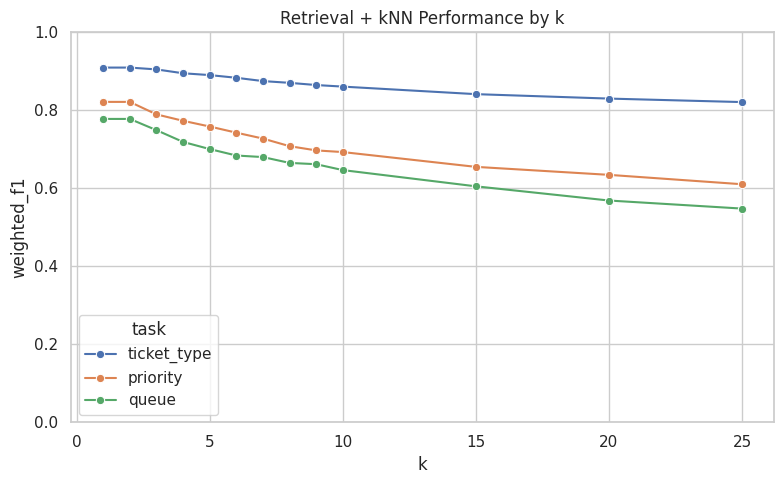

In [18]:
plot_rows = []
for task_name, k_df in k_search_results.items():
    tmp = k_df.copy()
    tmp['k'] = tmp['model'].str.extract(r'k(\d+)').astype(int)
    plot_rows.append(tmp)

k_plot_df = pd.concat(plot_rows, ignore_index=True)

plt.figure(figsize=(8, 5))
sns.lineplot(data=k_plot_df, x='k', y='weighted_f1', hue='task', marker='o')
plt.title('Retrieval + kNN Performance by k')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 8. Classification Reports and Confusion Matrices

Classification report for ticket_type:
              precision    recall  f1-score   support

      Change       0.97      0.94      0.96       341
    Incident       0.87      0.90      0.88      1314
     Problem       0.82      0.71      0.76       680
     Request       0.95      0.99      0.97       933

    accuracy                           0.89      3268
   macro avg       0.90      0.89      0.89      3268
weighted avg       0.89      0.89      0.89      3268



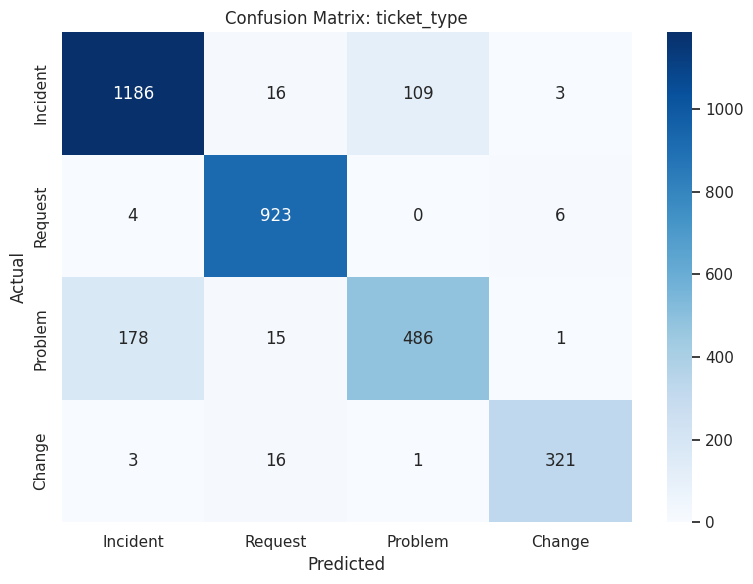

Classification report for priority:
              precision    recall  f1-score   support

        high       0.79      0.79      0.79      1269
         low       0.74      0.66      0.70       675
      medium       0.74      0.78      0.76      1324

    accuracy                           0.76      3268
   macro avg       0.76      0.74      0.75      3268
weighted avg       0.76      0.76      0.76      3268



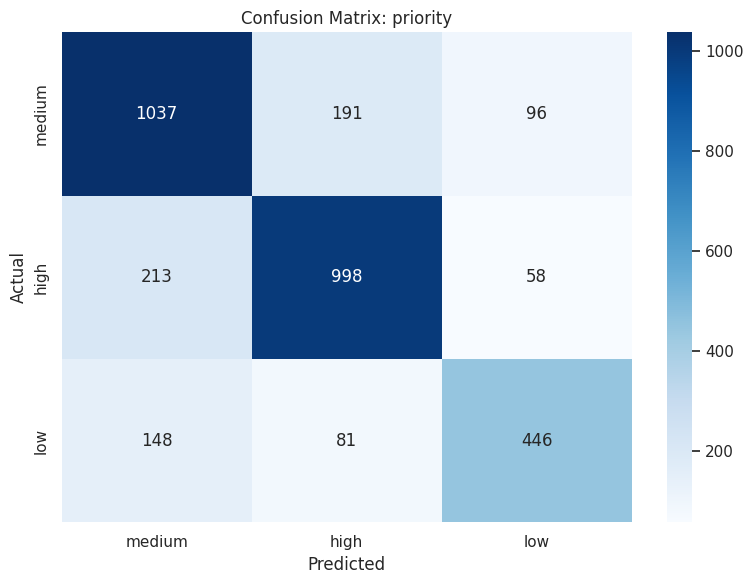

Classification report for queue:
                                 precision    recall  f1-score   support

           Billing and Payments       0.82      0.82      0.82       319
               Customer Service       0.66      0.68      0.67       482
                General Inquiry       0.68      0.55      0.61        47
                Human Resources       0.79      0.60      0.68        70
                     IT Support       0.65      0.60      0.63       388
                Product Support       0.68      0.69      0.68       615
          Returns and Exchanges       0.72      0.60      0.66       164
            Sales and Pre-Sales       0.72      0.59      0.65       103
Service Outages and Maintenance       0.77      0.73      0.75       133
              Technical Support       0.70      0.76      0.73       947

                       accuracy                           0.70      3268
                      macro avg       0.72      0.66      0.69      3268
                

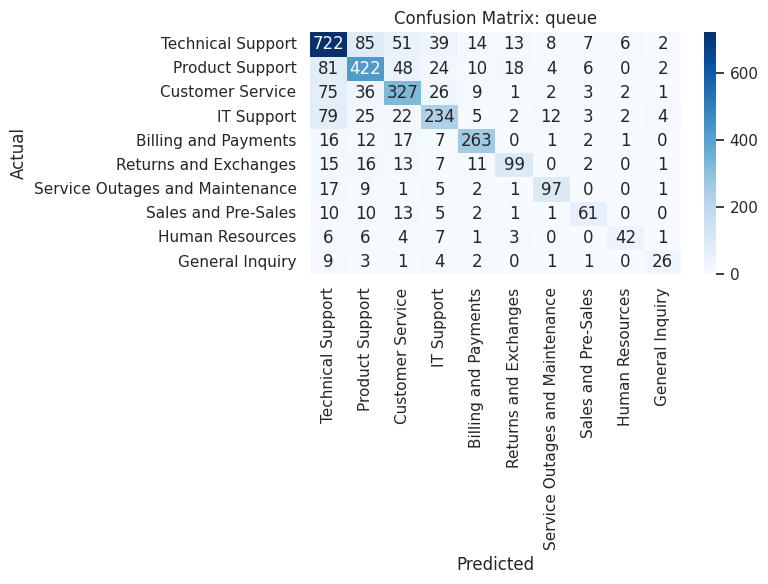

In [13]:
def show_task_report(task_name, task_bundle):
    y_test = task_bundle['result']['y_test']
    y_pred = task_bundle['result']['y_pred']

    print(f"Classification report for {task_name}:")
    print(classification_report(y_test, y_pred, zero_division=0))

    labels = y_test.value_counts().head(12).index.tolist()
    mask = y_test.isin(labels)
    cm = confusion_matrix(y_test[mask], y_pred[mask], labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix: {task_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

for task_name, task_bundle in all_results.items():
    show_task_report(task_name, task_bundle)

## 9. Inspect Retrieved Neighbors

This section shows example retrieved neighbors for one test ticket, which is useful for demonstrating the search/retrieval idea in the report.

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

def show_neighbors(task_name, index=0, top_k=5):
    bundle = all_results[task_name]['result']
    X_train = bundle['X_train']
    X_test = bundle['X_test']
    y_train = bundle['y_train']
    y_test = bundle['y_test']
    y_pred = bundle['y_pred']
    X_train_vec = bundle['X_train_vec']
    X_test_vec = bundle['X_test_vec']

    sims = cosine_similarity(X_test_vec[index], X_train_vec).ravel()
    top_idx = np.argsort(sims)[::-1][:top_k]

    print('Task:', task_name)
    print('Test ticket text:')
    print(X_test.iloc[index])
    print('\nTrue label:', y_test.iloc[index])
    print('Predicted label:', y_pred.iloc[index])
    print('\nTop retrieved neighbors:')

    rows = []
    for rank, idx in enumerate(top_idx, start=1):
        rows.append({
            'rank': rank,
            'similarity': sims[idx],
            'neighbor_label': y_train.iloc[idx],
            'neighbor_text': X_train.iloc[idx][:300],
        })
    display(pd.DataFrame(rows))


In [15]:
show_neighbors('priority', index=0, top_k=5)

Task: priority
Test ticket text:
Enhance User Interface for SaaS Project Management Experiencing difficulty navigating the platform. Would it be possible to update the interface to improve usability and efficiency?

True label: low
Predicted label: low

Top retrieved neighbors:


,rank,similarity,neighbor_label,neighbor_text
0,1,0.480670,low,Update User Interface Request to update the user interface color scheme to improve accessibility
1,2,0.360856,medium,Enhance User Interface The current UI is cumbersome. Please improve navigation aesthetics to enhance user experience...
2,3,0.345003,low,Enhance User Interface for Improved Navigation and User Experience Requesting an update to the user interface to imp...
3,4,0.344977,low,Enhance User Interface for Optimal Navigation Experience Requesting an update to the user interface to improve navig...
4,5,0.333611,low,Request to Update User Interface Color Scheme for Enhanced Accessibility Looking to improve the user interface color...
